# Initial wavefront sensor data analysis
francisho@lbl.gov, khchan@lbl.gov, awojdyla@lbl.gov

We want to provide an initial analysis of wavefront sensor data


In [8]:
import numpy as np
#load the api key from env var
import os
from tiled.client import from_uri
api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
if not api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")

# Initialize the Tiled server and client
tiled_client = from_uri("http://192.168.10.155:8000", api_key=api_key)

In [ ]:
import matplotlib.pyplot as plt
# uid for bender scan
uid = '67e37869-a3db-439d-b965-b3b70e50a698'
# magnification of the WFS camera setup
mag = 5
# pixel size of the camera in microns
px_cam_m = 2.4e-6 * 2 # we bin 2x2, so effective pixel size on camera is 4.8 um
# effective pixel size in the sample plane
px_img_m = px_cam_m/mag
stride_px = 0.1e-3/px_img_m
#print(f"Pixel stride in pixels: {stride_px:.1f} px")


db = tiled_client[uid]
data_list = db['primary']['basler_camera_image'].read()

In [5]:
# show the first image
plt.imshow(data_list[0], cmap='gray')
plt.show()

In [59]:
# scaling parameters
E_eV = 8000
px_m = (2.4e-6)/5 * 2 # effective pixel size in the sample plane

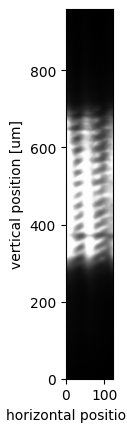

In [21]:
img_crop = data_list[80][200:1200, 570:700]
x_m = np.arange(img_crop.shape[1]) * px_m
y_m = np.arange(img_crop.shape[0]) * px_m
plt.imshow(img_crop, cmap='gray', extent=(x_m[0]*1e6, x_m[-1]*1e6, y_m[0]*1e6, y_m[-1]*1e6), origin='lower')
plt.xlabel('horizontal position [um]')
plt.ylabel('vertical position [um]')
plt.show()

Text(0, 0.5, 'vertical spatial frequency [1/m]')

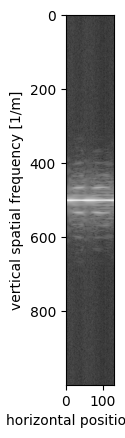

In [60]:
# Calculate frequency scale from spatial coordinates
freq_y_cpm = np.fft.fftshift(np.fft.fftfreq(img_crop.shape[0], px_m))

IMG_fft = np.fft.fftshift(np.fft.fft(img_crop,axis=0),axes=0)
IMG_fft_magnitude = np.abs(IMG_fft)
plt.imshow(IMG_fft_magnitude**0.1, cmap='gray')

plt.xlabel('horizontal position [um]')
plt.ylabel('vertical spatial frequency [1/m]')


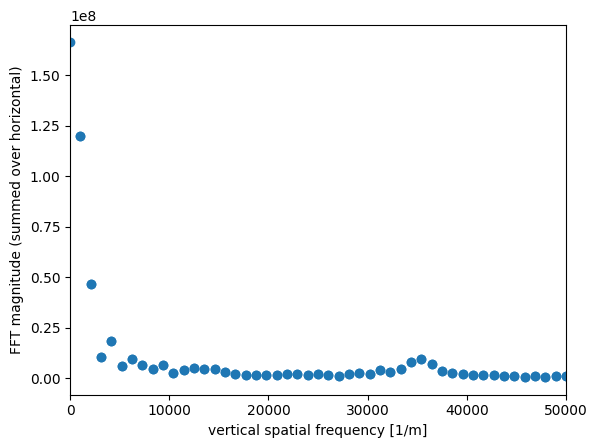

Peak frequency: 2.81e+04 1/m
Refined peak frequency: 3.13e+04 1/m


In [81]:
plt.scatter(np.abs(freq_y_cpm), np.sum(IMG_fft_magnitude, axis=1))
plt.xlabel('vertical spatial frequency [1/m]')
plt.ylabel('FFT magnitude (summed over horizontal)')
plt.xlim(0,5e4)
plt.show()
# find the peak in the FFT magnitude around the 0.28 cycles/um (which corresponds to 0.142857 cycles/micron in the original code)
idx = np.argmin(np.abs(freq_y_cpm - 0.28e5))
print(f"Peak frequency: {freq_y_cpm[idx]:.2e} 1/m")
# select the windows around the peak frequency and find the maximum in that window
window_size = 5e3 # 5 cycles/mm window
window_idx = np.where((freq_y_cpm > (freq_y_cpm[idx] - window_size)) & (freq_y_cpm < (freq_y_cpm[idx] + window_size)))[0]
peak_idx = window_idx[np.argmax(np.sum(IMG_fft_magnitude[window_idx,:], axis=1))]
print(f"Refined peak frequency: {freq_y_cpm[peak_idx]:.2e} 1/m")

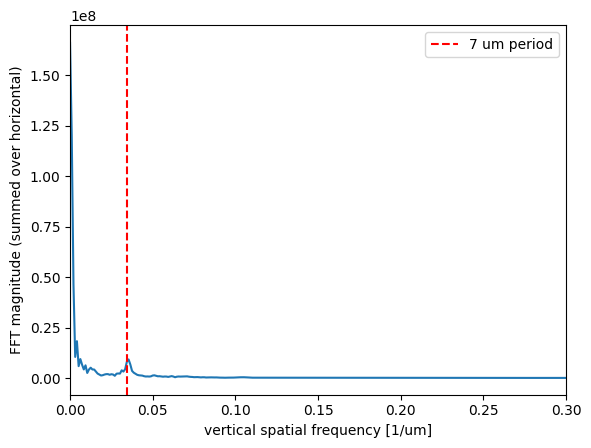

In [88]:
x_vals = freq_y_cpm * 1e-6
y_vals = data_list[0][200:1200, 570:700]
# calculate the fft along the vertical direction for the cropped image and sum over the horizontal direction
y_vals = np.abs(np.fft.fftshift(np.fft.fft(img_crop, axis=0), axes=0))

idx = np.argmin(np.abs(x_vals - 0.0345))
# plot the power spectrum and annotate the peak corresponding to 7 um period (0.142857 cycles/um)
plt.plot(x_vals, np.sum(y_vals, axis=1))
plt.xlabel('vertical spatial frequency [1/um]')
plt.ylabel('FFT magnitude (summed over horizontal)')
plt.xlim(0, 0.3)
plt.axvline(0.0345, color='red', linestyle='--', label='7 um period')
plt.legend()
plt.show()

## Bender data

In [26]:
db = tiled_client[uid]
images_bend = db['primary']['basler_camera_image'].read()
bends_um = db['primary']['bender_um'].read()


In [28]:
print(len(images_bend))

211


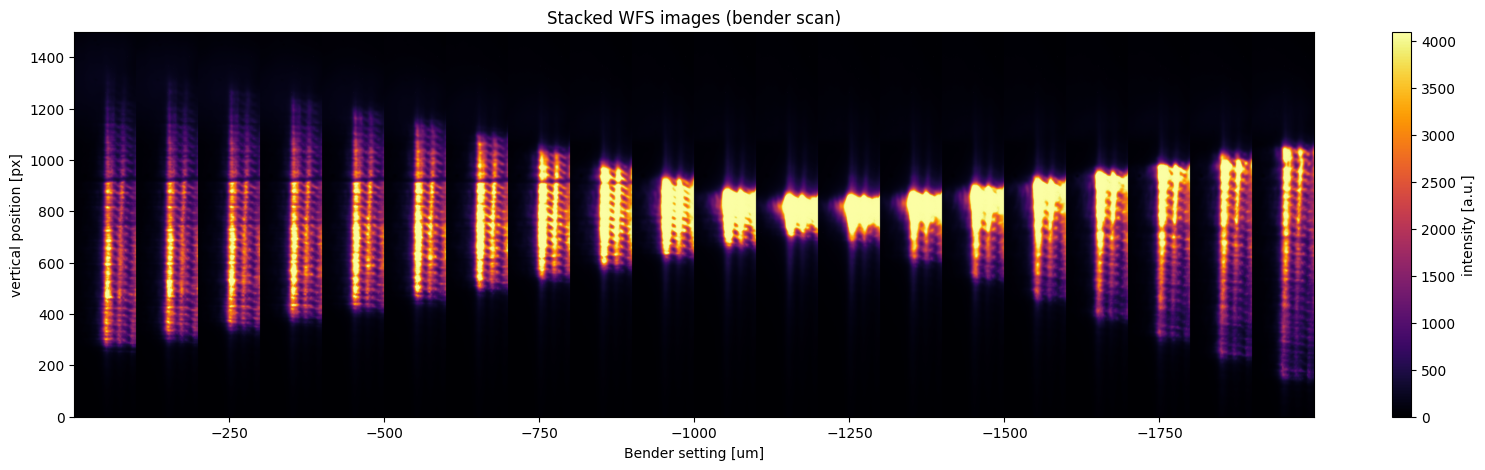

In [36]:
# Stack the cropped images from energy scan horizontally
img_stack = np.hstack([images_bend[10*i][:, 400:700] for i in range(20)])

plt.figure(figsize=(20, 5))
plt.imshow(img_stack, cmap='inferno', aspect='auto', 
           extent=(bends_um[0], bends_um[-1], 0, img_stack.shape[0]), origin='upper')
plt.xlabel('Bender setting [um]')
plt.ylabel('vertical position [px]')
plt.title('Stacked WFS images (bender scan)')
plt.colorbar(label='intensity [a.u.]')
plt.show()

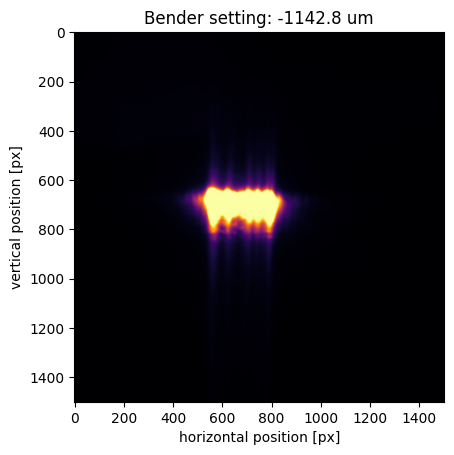

In [172]:
idx = 120
plt.imshow(images_bend[idx][:,:], cmap='inferno')
plt.xlabel('horizontal position [px]')
plt.ylabel('vertical position [px]')
plt.title(f'Bender setting: {bends_um[idx]:.1f} um') 
plt.show()

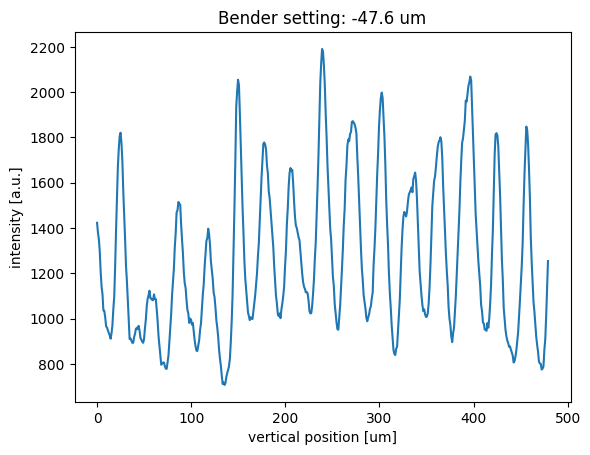

In [89]:
idx = 5
bend_line = images_bend[idx][600:1100,650]
y_m = np.arange(bend_line.shape[0]) * px_m
plt.plot(y_m*1e6, bend_line)
plt.xlabel('vertical position [um]')
plt.ylabel('intensity [a.u.]')
plt.title(f'Bender setting: {bends_um[idx]:.1f} um')
plt.show()

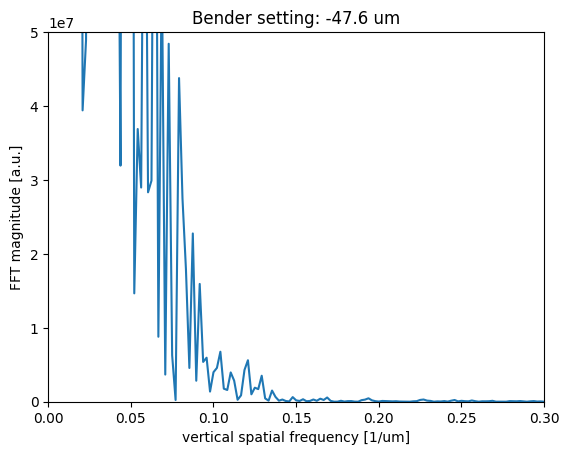

In [90]:
img_FFT = np.fft.fftshift(np.fft.fft(bend_line, axis=0), axes=0)
freq_y_cpm = np.fft.fftshift(np.fft.fftfreq(bend_line.shape[0], px_m))
plt.plot(freq_y_cpm*1e-6, np.abs(img_FFT)**2)
plt.xlabel('vertical spatial frequency [1/um]')     
plt.ylabel('FFT magnitude [a.u.]')
plt.title(f'Bender setting: {bends_um[idx]:.1f} um')
plt.xlim((0, 0.3))
plt.ylim((0, 0.5e8))
plt.show()

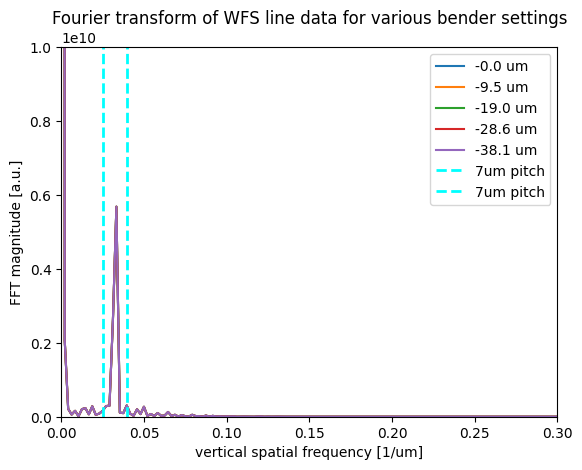

In [185]:
for i_p in range(5):
    line = images_bend[idx][600:1100,650]
    line_FFT = np.fft.fftshift(np.fft.fft(line, axis=0), axes=0)
    freq_y_cpm = np.fft.fftshift(np.fft.fftfreq(line.shape[0], px_m))
    plt.plot(freq_y_cpm*1e-6, np.abs(line_FFT)**2, label=f'{bends_um[i_p]:.1f} um')
plt.xlabel('vertical spatial frequency [1/um]')
plt.ylabel('FFT magnitude [a.u.]')
plt.title('Fourier transform of WFS line data for various bender settings')
plt.xlim((0, 0.3))
plt.ylim((0, 1e10))

plt.axvline(0.025, color='cyan', linestyle='--', linewidth=2, label='7um pitch')
plt.axvline(0.04, color='cyan', linestyle='--', linewidth=2, label='7um pitch')
plt.legend()
plt.show()

## wavefront processing

we base our analysis on Francis' script:
https://github.com/dream-beam/dream-test/blob/main/WavefrontSensor/Notebooks/Wavefront_Sensing_Simulation_v2.2.ipynb

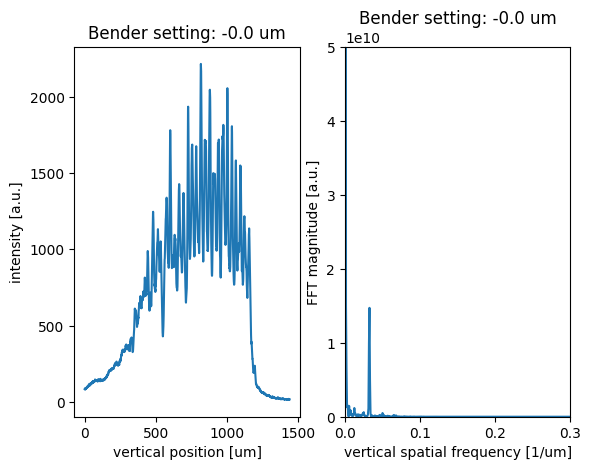

In [151]:
idx = 0
bend_line = images_bend[idx][:,650]
y_m = np.arange(bend_line.shape[0]) * px_m

plt.subplot(1, 2, 1)
plt.plot(y_m*1e6, bend_line)
plt.xlabel('vertical position [um]')
plt.ylabel('intensity [a.u.]')
plt.title(f'Bender setting: {bends_um[idx]:.1f} um')


img_FFT = np.fft.fftshift(np.fft.fft(bend_line, axis=0), axes=0)
freq_y_cpm = np.fft.fftshift(np.fft.fftfreq(bend_line.shape[0], px_m))

plt.subplot(1, 2, 2)
plt.plot(freq_y_cpm*1e-6, np.abs(img_FFT)**2)
plt.xlabel('vertical spatial frequency [1/um]')     
plt.ylabel('FFT magnitude [a.u.]')
plt.title(f'Bender setting: {bends_um[idx]:.1f} um')
plt.xlim((0, 0.3))
plt.ylim((0, 5e10))
plt.show()

In [152]:
grating_pitch_m = 7e-6
grating_freq_cpm = 1/grating_pitch_m
photon_energy_eV = 8000
wavelength_m = 1234e-9/photon_energy_eV

z_to_grating_m = 300e-3                         # Source to grating [m]
z_T_m = grating_pitch_m**2 / wavelength_m       # Talbot distance (grating to detector) [m]


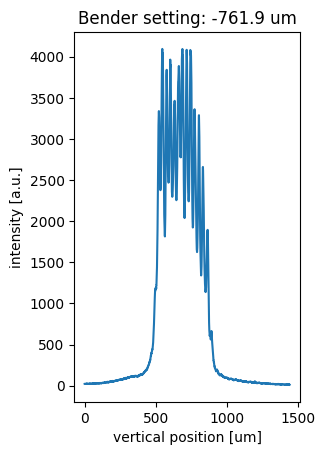

In [153]:
from scipy.signal import find_peaks

idx = 80
bend_line = images_bend[idx][:,650]
y_m = np.arange(bend_line.shape[0]) * px_m

plt.subplot(1, 2, 1)
plt.plot(y_m*1e6, bend_line)
plt.xlabel('vertical position [um]')
plt.ylabel('intensity [a.u.]')
plt.title(f'Bender setting: {bends_um[idx]:.1f} um')


img_FFT = np.fft.fftshift(np.fft.fft(bend_line, axis=0), axes=0)
# Transform intensity pattern to frequency domain
I_fft = img_FFT

# Create frequency array
freq = freq_y_cpm
M = len(freq)
df = freq[1]-freq[0]  # Frequency resolution [1/m]

mask = (freq > 0.025e6) & (freq < 0.045e6)

# Find peaks in FFT spectrum (use magnitude)
I_fft_magnitude = np.abs(I_fft)
peaks, properties = find_peaks(I_fft_magnitude*mask, height=np.max(I_fft_magnitude*mask)*0.1)

# Identify carrier frequency (should be at ±1/pitch)
#carrier_freq_ideal = 1 / grating_pitch_m
carrier_freq_ideal = 0.0345e6 # 34.5 cycles/mm, which is 0.0345 cycles/um
carrier_idx = peaks[np.argmin(np.abs(freq[peaks] - carrier_freq_ideal))]
#carrier_idx = np.argmax(I_fft_magnitude*mask)
carrier_freq_measured = freq[carrier_idx]


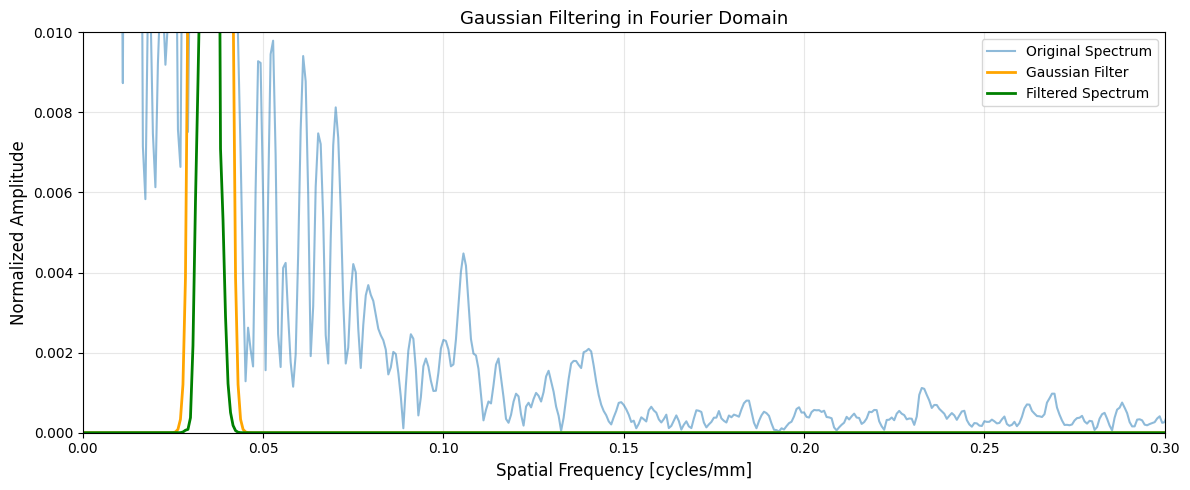

In [154]:
# Create Gaussian filter centered on +1 order
filter_width = 3.0  # pixels (standard deviation)
x_indices = np.arange(M)
gaussian_filter = np.exp(-0.5 * ((x_indices - carrier_idx) / filter_width)**2)

# Apply filter to FFT
I_fft_filtered = I_fft * gaussian_filter

# Normalize for visualization (so all curves are visible on same plot)
I_fft_magnitude_norm = I_fft_magnitude / np.max(I_fft_magnitude)
I_fft_filtered_norm = np.abs(I_fft_filtered) / np.max(np.abs(I_fft_magnitude))

# Visualize filtering
plt.figure(figsize=(12, 5))
plt.plot(freq*1e-6, I_fft_magnitude_norm, label='Original Spectrum', alpha=0.5)
plt.plot(freq*1e-6, gaussian_filter, label='Gaussian Filter', linewidth=2, color='orange')
plt.plot(freq*1e-6, I_fft_filtered_norm, 
         label='Filtered Spectrum', linewidth=2, color='green')
plt.xlabel('Spatial Frequency [cycles/mm]', fontsize=12)
plt.ylabel('Normalized Amplitude', fontsize=12)
plt.title('Gaussian Filtering in Fourier Domain', fontsize=13)
plt.xlim(0,0.3)
plt.ylim(0, 1e-2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

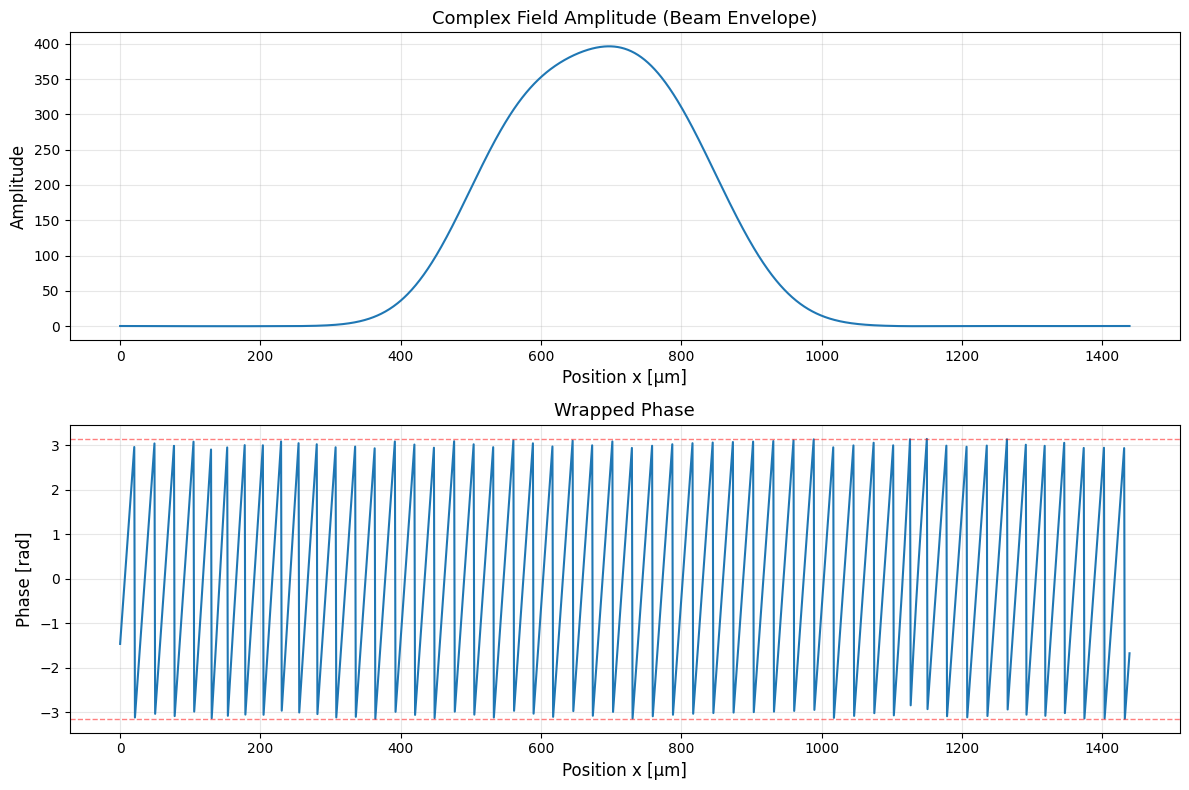

In [155]:
# Inverse FFT to get complex field
complex_field = np.fft.ifft(np.fft.ifftshift(I_fft_filtered))

# Extract amplitude and wrapped phase
amplitude = np.abs(complex_field)
phase_wrapped = np.angle(complex_field)

# Visualize complex field
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Amplitude (beam envelope)
ax = axes[0]
ax.plot(y_m*1e6, amplitude, linewidth=1.5)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Amplitude', fontsize=12)
ax.set_title('Complex Field Amplitude (Beam Envelope)', fontsize=13)
ax.grid(True, alpha=0.3)

# Wrapped phase
ax = axes[1]
ax.plot(y_m*1e6, phase_wrapped, linewidth=1.5)
ax.axhline(np.pi, color='r', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(-np.pi, color='r', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Phase [rad]', fontsize=12)
ax.set_title('Wrapped Phase', fontsize=13)
ax.set_ylim(-np.pi*1.1, np.pi*1.1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

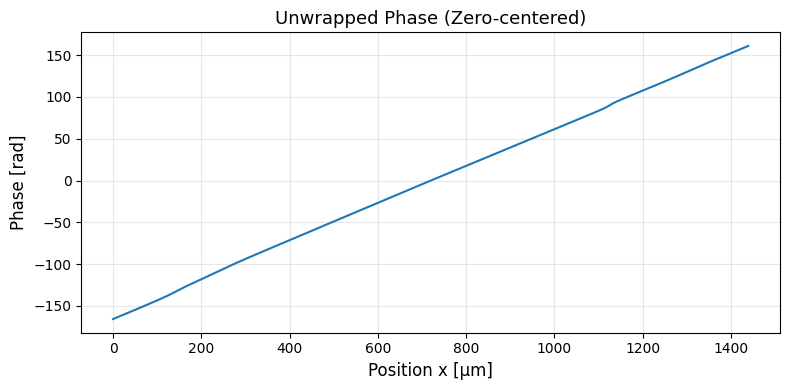

In [156]:
# Standard unwrap (left-to-right) and center at x=0
phase_unwrapped = np.unwrap(phase_wrapped)

y_px = np.arange(len(bend_line))
beam_center_estimate_px = np.sum(y_px*bend_line)/np.sum(bend_line)#moment: sum of values * their position / sum of all values
phase_centered = phase_unwrapped - phase_unwrapped[M//2]
#phase_centered = phase_unwrapped - phase_unwrapped[int(beam_center_estimate_px)]

# Visualize only the unwrapped and centered phase
plt.figure(figsize=(8, 4))
plt.plot(y_m*1e6, phase_centered, linewidth=1.5)
plt.xlabel('Position x [μm]', fontsize=12)
plt.ylabel('Phase [rad]', fontsize=12)
plt.title('Unwrapped Phase (Zero-centered)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

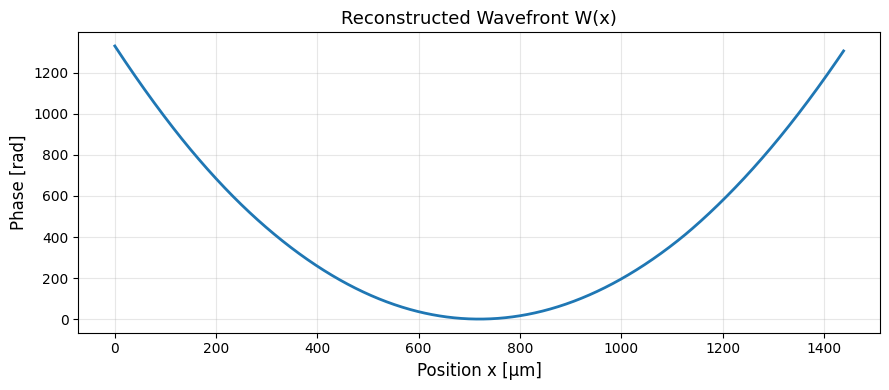

In [157]:
dy_m = y_m[1] - y_m[0]  # Spatial sampling interval [m]
# Simple cumulative integration with scaling
wavefront_temp = np.cumsum(phase_centered) * dy_m * grating_pitch_m / wavelength_m / 2

# Re-center at x=0 to remove piston term
wavefront_reconstructed = wavefront_temp - wavefront_temp[M//2]

# Plot reconstructed wavefront
plt.figure(figsize=(9, 4))
plt.plot(y_m*1e6, wavefront_reconstructed, linewidth=2)
plt.xlabel('Position x [μm]', fontsize=12)
plt.ylabel('Phase [rad]', fontsize=12)
plt.title('Reconstructed Wavefront W(x)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



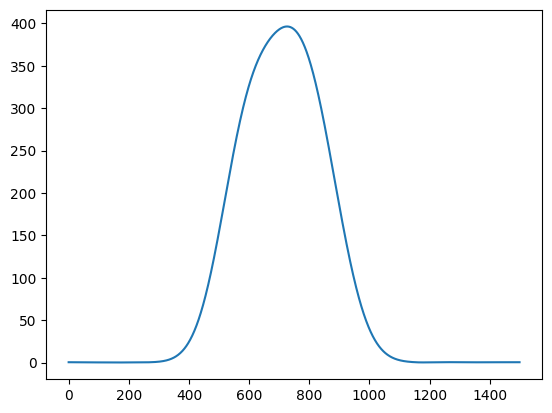

In [158]:
field = amplitude*np.exp(1j*wavefront_reconstructed)
plt.plot(amplitude)

In [159]:
wavefront_list = []
fields_list = []
for i_b in range(10):
    line = images_bend[i_b*20][:,650]
    line_FFT = np.fft.fftshift(np.fft.fft(line, axis=0), axes=0)
    freq_y_cpm = np.fft.fftshift(np.fft.fftfreq(line.shape[0], px_m))

    #from scipy.signal import find_peaks

    # Transform intensity pattern to frequency domain
    I_fft = line_FFT

    # Create frequency array
    freq = freq_y_cpm
    M = len(freq)
    df = freq[1]-freq[0]  # Frequency resolution [1/m]

    mask = (freq > 0.025e6) & (freq < 0.045e6)

    # Find peaks in FFT spectrum (use magnitude)
    I_fft_magnitude = np.abs(I_fft)
    # peaks, properties = find_peaks(I_fft_magnitude*mask, height=np.max(I_fft_magnitude*mask)*0.1)

    # Identify carrier frequency (should be at ±1/pitch)
    carrier_freq_ideal = 0.0345e6 # 34.5 cycles/mm, which is 0.0345 cycles/um
    carrier_idx = peaks[np.argmin(np.abs(freq[peaks] - carrier_freq_ideal))]
    #carrier_idx = np.argmax(I_fft_magnitude*mask)
    carrier_freq_measured = freq[carrier_idx]


    # Create Gaussian filter centered on +1 order
    filter_width = 10.0  # pixels (standard deviation)
    x_indices = np.arange(M)
    gaussian_filter = np.exp(-0.5 * ((x_indices - carrier_idx) / filter_width)**2)

    # Apply filter to FFT
    I_fft_filtered = I_fft * gaussian_filter

    # Normalize for visualization (so all curves are visible on same plot)
    I_fft_magnitude_norm = I_fft_magnitude / np.max(I_fft_magnitude)
    I_fft_filtered_norm = np.abs(I_fft_filtered) / np.max(np.abs(I_fft_magnitude))

    # Inverse FFT to get complex field
    complex_field = np.fft.ifft(np.fft.ifftshift(I_fft_filtered))

    # Extract amplitude and wrapped phase
    amplitude = np.abs(complex_field)
    phase_wrapped = np.angle(complex_field)

    # Standard unwrap (left-to-right) and center at x=0
    phase_unwrapped = np.unwrap(phase_wrapped)
    phase_centered = phase_unwrapped - phase_unwrapped[M//2]

    dy_m = y_m[1] - y_m[0]  # Spatial sampling interval [m]
    # Simple cumulative integration with scaling
    wavefront_temp = np.cumsum(phase_centered) * dy_m * grating_pitch_m / wavelength_m / 2

    # Re-center at x=0 to remove piston term
    wavefront_reconstructed = wavefront_temp - wavefront_temp[M//2]
    wavefront_list.append(wavefront_reconstructed)
    fields_list.append(amplitude*np.exp(1j*wavefront_reconstructed))

    # # Plot reconstructed wavefront
    # plt.figure(figsize=(9, 4))
    # plt.plot(y_m*1e6, wavefront_reconstructed, linewidth=2)
    # plt.xlabel('Position x [μm]', fontsize=12)
    # plt.ylabel('Phase [rad]', fontsize=12)
    # plt.title('Reconstructed Wavefront W(x)', fontsize=13)
    # plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    # plt.show()


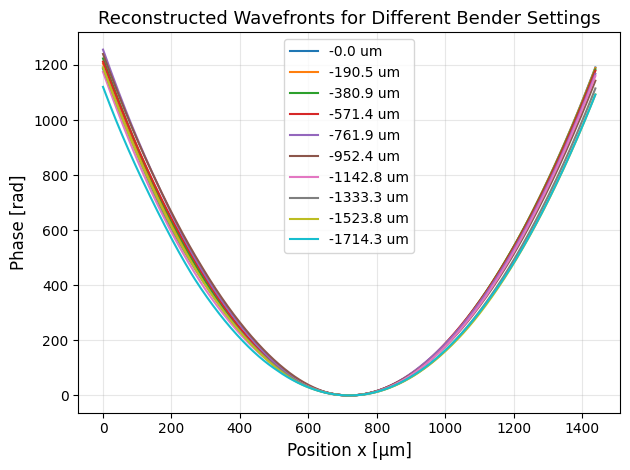

In [160]:
for i_b in range(10):
    plt.plot(y_m*1e6, wavefront_list[i_b], label=f'{bends_um[i_b*20]:.1f} um')
    #plt.plot(y_m*1e6, wavefront_list[i_b]-(wavefront_list[0]), label=f'{bends_um[i_b]:.1f} um (centered)')
plt.xlabel('Position x [μm]', fontsize=12)
plt.ylabel('Phase [rad]', fontsize=12)
plt.title('Reconstructed Wavefronts for Different Bender Settings', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


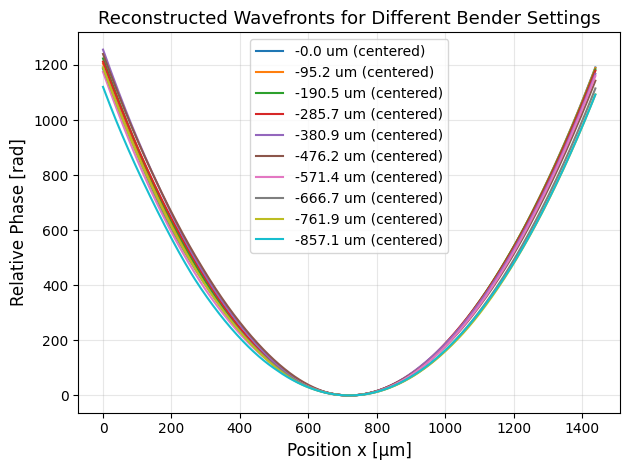

In [ ]:
for i_b in range(20):
    #plt.plot(y_m*1e6, wavefront_list[i_b], label=f'{bends_um[i_b]:.1f} um')
    plt.plot(y_m*1e6, wavefront_list[i_b], label=f'{bends_um[i_b*10]:.1f} um (centered)')
plt.xlabel('Position x [μm]', fontsize=12)
plt.ylabel('Relative Phase [rad]', fontsize=12)
plt.title('Reconstructed Wavefronts for Different Bender Settings', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


IndexError: list index out of range

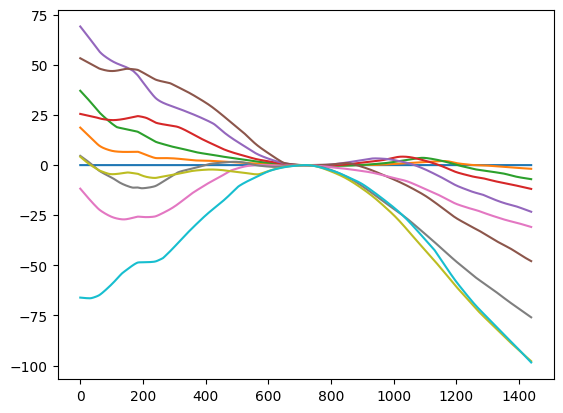

In [184]:
for i_b in range(20):
    #plt.plot(y_m*1e6, wavefront_list[i_b], label=f'{bends_um[i_b]:.1f} um')
    plt.plot(y_m*1e6, wavefront_list[i_b]-wavefront_list[0], label=f'{bends_um[i_b*10]:.1f} um (centered)')
plt.xlabel('Position x [μm]', fontsize=12)
plt.ylabel('Relative Phase [rad]', fontsize=12)
plt.title('Reconstructed Wavefronts for Different Bender Settings', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


IndexError: index 1600 is out of bounds for axis 1 with size 1500

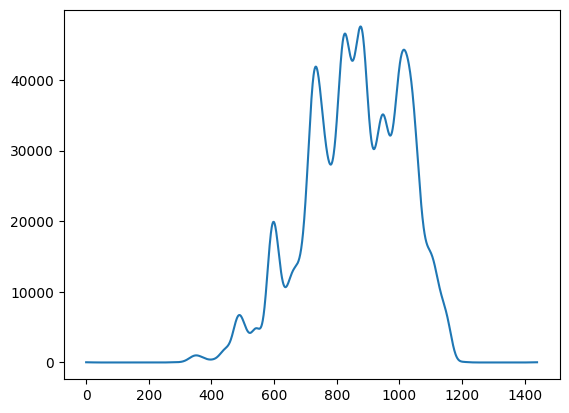

In [173]:
idx = 0
plt.plot(y_m*1e6, np.abs(fields_list[idx])**2, label='Reconstructed Intensity')
plt.plot(y_m*1e6, images_bend[idx][:,1600], label='Original Intensity')
plt.xlabel('Position y [μm]', fontsize=12)
plt.ylabel('Intensity [a.u.]', fontsize=12)
plt.title('Reconstructed Intensity Profile', fontsize=13)

## caustics

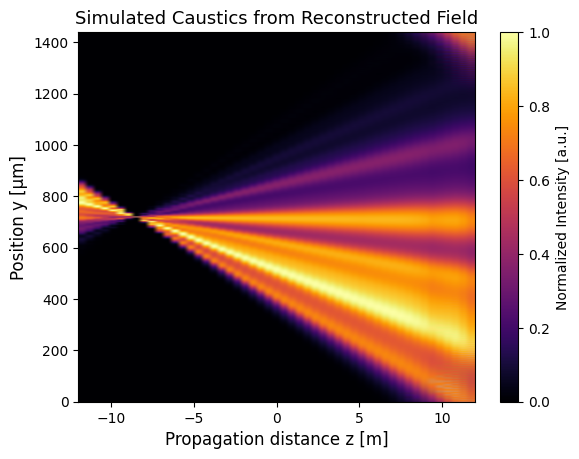

In [183]:
def propTF(uin_V_m, L_m, lambda_m, z_m):
    M = uin_V_m.size        # number of samples (grid points)
    dx_m = L_m/M            # grid spacing
    k_1_m = 2*np.pi/lambda_m # wavenumber

    # Frequency coordinates
    fx_1_m = np.linspace(-1/(2*dx_m), 1/(2*dx_m) - (1/L_m), M)
    
    # Transfer function for Fresnel propagation
    H = np.exp(-1j * np.pi * lambda_m * z_m * (fx_1_m**2))
    H = np.fft.fftshift(H)

    # Fourier transform input field
    Uin_V_m = np.fft.fft(np.fft.fftshift(uin_V_m))

    # Multiply in Fourier space
    Uout_V_m = H * Uin_V_m

    # Inverse FFT → propagated field
    uout_V_m = np.fft.ifftshift(np.fft.ifft(Uout_V_m))
    return uout_V_m

idx = 1
L_m = y_m[-1]-y_m[0]

z_range_m = np.linspace(-12,12,51)
caustics = np.zeros((len(y_m),len(z_range_m)))
for i_z in range(len(z_range_m)):
    caustics[:,i_z] = np.abs(propTF(fields_list[idx], L_m, wavelength_m, z_range_m[i_z]))**2
    caustics[:,i_z] /= np.max(caustics[:,i_z])  # Normalize each column for better visualization
plt.imshow(caustics, extent=(z_range_m[0], z_range_m[-1], y_m[0]*1e6, y_m[-1]*1e6), aspect='auto', cmap='inferno')
plt.xlabel('Propagation distance z [m]', fontsize=12)
plt.ylabel('Position y [μm]', fontsize=12)
plt.title('Simulated Caustics from Reconstructed Field', fontsize=13)
plt.colorbar(label='Normalized Intensity [a.u.]')
plt.show()